ID seeds: [42]
OOD seeds: [42]

ID — single_head_frozen
 year             method   mean std  n ci_low ci_high
 2012 single_head_frozen 0.7899 NaN  1    NaN     NaN
 2013 single_head_frozen 0.7832 NaN  1    NaN     NaN
 2014 single_head_frozen 0.6863 NaN  1    NaN     NaN
 2015 single_head_frozen 0.7021 NaN  1    NaN     NaN

OOD supervised reference — single_head_supervised_reference
 year                           method   mean std  n ci_low ci_high
 2016 single_head_supervised_reference 0.7117 NaN  1    NaN     NaN
 2017 single_head_supervised_reference 0.7116 NaN  1    NaN     NaN
 2018 single_head_supervised_reference 0.7519 NaN  1    NaN     NaN

OOD — single_head_frozen
 year             method   mean std  n ci_low ci_high
 2016 single_head_frozen 0.6537 NaN  1    NaN     NaN
 2017 single_head_frozen 0.6280 NaN  1    NaN     NaN
 2018 single_head_frozen 0.6671 NaN  1    NaN     NaN

OOD — metadata
 year   method   mean std  n ci_low ci_high
 2016 metadata 0.6542 NaN  1    NaN    

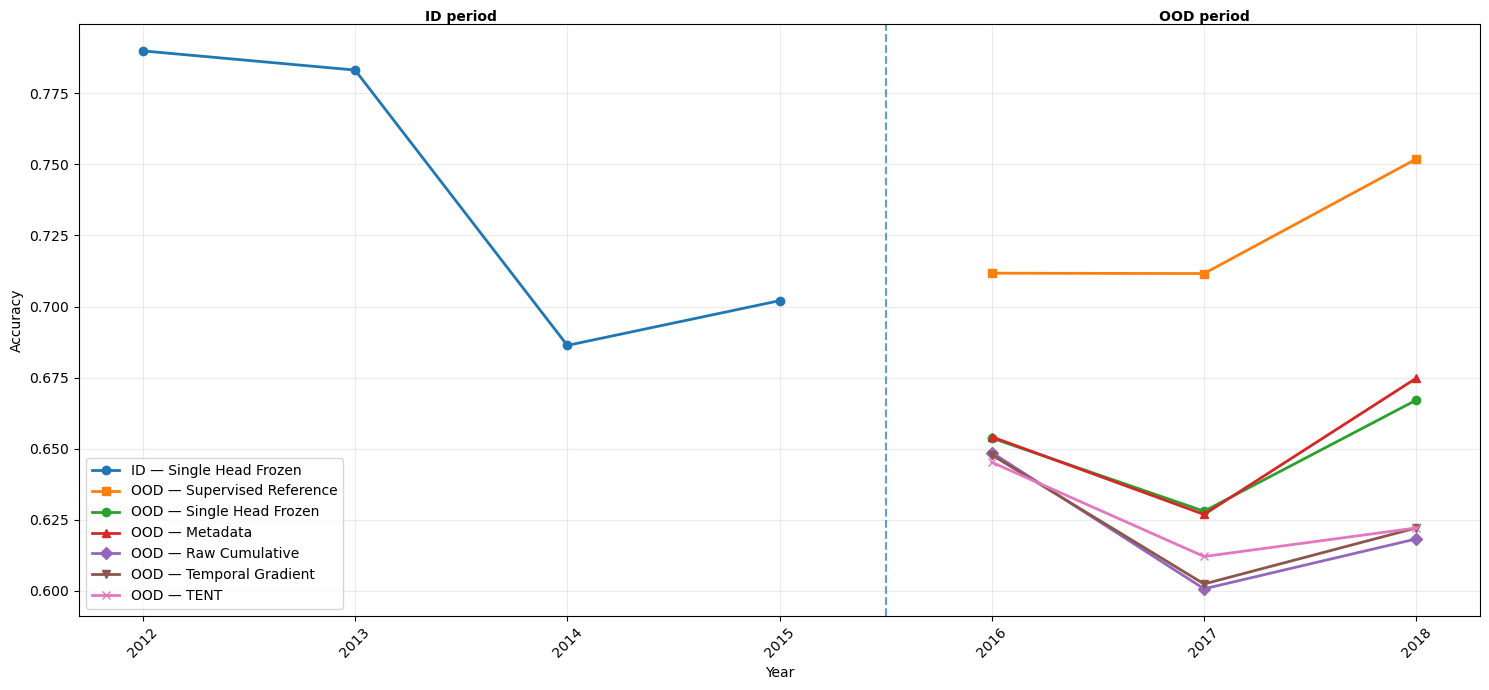

In [4]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


# ============================================================
# CONFIG
# ============================================================

# ------------------------------------------------------------
# DATASET / PATHS
# ------------------------------------------------------------

RESULTS_DIR = Path("results/huffpost/eval_stream_tas")

ID_FILE_PATTERN = "id_*.csv"
OOD_FILE_PATTERN = "ood_*.csv"

EXPECTED_SEEDS = {42}

CI_LEVEL = 0.95


# ------------------------------------------------------------
# TEMPORAL SPLIT
# ------------------------------------------------------------

# Periodo ID "storico"
ID_START_YEAR = 2012
ID_END_YEAR = 2015

# Periodo OOD / TAS
OOD_START_YEAR = 2016
OOD_END_YEAR = 2018

# Linea verticale tra ID e OOD.
# Normalmente non serve modificarla.
SPLIT_X = (ID_END_YEAR + OOD_START_YEAR) / 2


# ------------------------------------------------------------
# METHODS
# ------------------------------------------------------------

# Metodo mostrato nel periodo ID
ID_BASELINE_METHOD = "single_head_frozen"

# Oracle / supervised reference nel periodo OOD
SUPERVISED_REFERENCE_METHOD = "single_head_supervised_reference"

# Metodi da confrontare nel periodo OOD
OOD_METHODS = [
    "single_head_frozen",
    "metadata",
    "raw_cumulative",
    "temporal_gradient",
    "tent",
]


# ------------------------------------------------------------
# DISPLAY NAMES + MARKERS
# ------------------------------------------------------------

METHOD_SPECS = {
    "single_head_frozen": {
        "label": "Single Head Frozen",
        "marker": "o",
    },
    "single_head_supervised_reference": {
        "label": "Supervised Reference",
        "marker": "s",
    },
    "metadata": {
        "label": "Metadata",
        "marker": "^",
    },
    "raw_cumulative": {
        "label": "Raw Cumulative",
        "marker": "D",
    },
    "temporal_gradient": {
        "label": "Temporal Gradient",
        "marker": "v",
    },
    "tent": {
        "label": "TENT",
        "marker": "x",
    },
}


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

FIGSIZE = (15, 7)

SHOW_CONFIDENCE_INTERVAL = True
CI_ALPHA = 0.15

SHOW_PERIOD_LABELS = True
SHOW_SPLIT_LINE = True

Y_LABEL = "Accuracy"
X_LABEL = "Year"

GRID_ALPHA = 0.25


# ============================================================
# HELPERS
# ============================================================

def extract_seed(path: Path) -> int:
    """
    Estrae il seed dal nome del file.

    Esempi:
        id_42.csv  -> 42
        ood_46.csv -> 46
    """
    match = re.search(r"_(\d+)\.csv$", path.name)

    if match is None:
        raise ValueError(
            f"Impossibile estrarre il seed da: {path.name}"
        )

    return int(match.group(1))


def load_seed_files(pattern: str) -> pd.DataFrame:
    """
    Carica tutti i CSV che rispettano il pattern e aggiunge
    una colonna 'seed' estratta dal filename.
    """

    files = sorted(RESULTS_DIR.glob(pattern))

    if not files:
        raise FileNotFoundError(
            f"Nessun file trovato con pattern '{pattern}' "
            f"in {RESULTS_DIR.resolve()}"
        )

    dfs = []

    for path in files:
        seed = extract_seed(path)

        df = pd.read_csv(path)

        required_columns = {
            "year",
            "method",
            "accuracy",
        }

        missing = required_columns - set(df.columns)

        if missing:
            raise ValueError(
                f"{path.name}: mancano le colonne {missing}. "
                f"Colonne presenti: {list(df.columns)}"
            )

        df = df[
            ["year", "method", "accuracy"]
        ].copy()

        df["seed"] = seed

        df["year"] = pd.to_numeric(
            df["year"],
            errors="raise",
        )

        df["accuracy"] = pd.to_numeric(
            df["accuracy"],
            errors="raise",
        )

        dfs.append(df)

    return pd.concat(
        dfs,
        ignore_index=True,
    )


def check_seeds(
    df: pd.DataFrame,
    name: str,
):
    found_seeds = set(
        df["seed"].unique()
    )

    print(
        f"{name} seeds:",
        sorted(found_seeds),
    )

    if EXPECTED_SEEDS is not None:
        if found_seeds != EXPECTED_SEEDS:
            print(
                f"WARNING: seed {name} trovati "
                f"{sorted(found_seeds)}, "
                f"attesi {sorted(EXPECTED_SEEDS)}"
            )


def compute_stats(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calcola per ogni year/method:

      - mean
      - sample std
      - n
      - standard error
      - Student-t CI
    """

    stats = (
        df
        .groupby(
            ["year", "method"]
        )["accuracy"]
        .agg(
            mean="mean",
            std="std",
            n="count",
        )
        .reset_index()
    )

    stats["sem"] = (
        stats["std"]
        / np.sqrt(stats["n"])
    )

    alpha = 1 - CI_LEVEL

    stats["t_critical"] = (
        stats["n"]
        .apply(
            lambda n: (
                t.ppf(
                    1 - alpha / 2,
                    df=n - 1,
                )
                if n > 1
                else np.nan
            )
        )
    )

    stats["ci_half"] = (
        stats["t_critical"]
        * stats["sem"]
    )

    stats["ci_low"] = (
        stats["mean"]
        - stats["ci_half"]
    )

    stats["ci_high"] = (
        stats["mean"]
        + stats["ci_half"]
    )

    return stats


def select_method(
    stats: pd.DataFrame,
    method: str,
) -> pd.DataFrame:
    return stats[
        stats["method"] == method
    ].copy()


def select_period(
    df: pd.DataFrame,
    year_start: int,
    year_end: int,
) -> pd.DataFrame:
    return df[
        (df["year"] >= year_start)
        & (df["year"] <= year_end)
    ].copy()


def print_method_stats(
    title: str,
    df: pd.DataFrame,
):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    if df.empty:
        print("Nessun risultato trovato.")
        return

    display_df = df[
        [
            "year",
            "method",
            "mean",
            "std",
            "n",
            "ci_low",
            "ci_high",
        ]
    ].copy()

    print(
        display_df.to_string(
            index=False,
            formatters={
                "mean": "{:.4f}".format,
                "std": "{:.4f}".format,
                "ci_low": "{:.4f}".format,
                "ci_high": "{:.4f}".format,
            },
        )
    )


def global_stats(
    df: pd.DataFrame,
    method: str,
    year_start: int,
    year_end: int,
):
    """
    Summary globale ottenuta mettendo insieme
    tutte le osservazioni anno × seed.

    Esempio:
        2013-2017 × 5 seed = 25 valori.
    """

    subset = df[
        (df["method"] == method)
        & (df["year"] >= year_start)
        & (df["year"] <= year_end)
    ].copy()

    values = (
        subset["accuracy"]
        .dropna()
    )

    n = len(values)

    if n == 0:
        return {
            "method": method,
            "years": f"{year_start}-{year_end}",
            "mean": np.nan,
            "std": np.nan,
            "n": 0,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    mean = values.mean()

    if n == 1:
        return {
            "method": method,
            "years": f"{year_start}-{year_end}",
            "mean": mean,
            "std": np.nan,
            "n": n,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    std = values.std(
        ddof=1
    )

    sem = (
        std
        / np.sqrt(n)
    )

    t_critical = t.ppf(
        1 - (1 - CI_LEVEL) / 2,
        df=n - 1,
    )

    ci_half = (
        t_critical
        * sem
    )

    return {
        "method": method,
        "years": f"{year_start}-{year_end}",
        "mean": mean,
        "std": std,
        "n": n,
        "ci_low": mean - ci_half,
        "ci_high": mean + ci_half,
    }


def get_method_spec(
    method: str,
):
    """
    Restituisce automaticamente un label e marker
    anche se il metodo non è presente in METHOD_SPECS.
    """

    default = {
        "label": method.replace("_", " ").title(),
        "marker": "o",
    }

    return METHOD_SPECS.get(
        method,
        default,
    )


def plot_with_ci(
    ax,
    df,
    label,
    marker="o",
    linewidth=2,
    linestyle="-",
):
    if df.empty:
        return

    df = df.sort_values(
        "year"
    )

    x = df["year"].to_numpy()
    y = df["mean"].to_numpy()

    line, = ax.plot(
        x,
        y,
        marker=marker,
        linewidth=linewidth,
        linestyle=linestyle,
        label=label,
    )

    if SHOW_CONFIDENCE_INTERVAL:
        ci_low = (
            df["ci_low"]
            .to_numpy()
        )

        ci_high = (
            df["ci_high"]
            .to_numpy()
        )

        ax.fill_between(
            x,
            ci_low,
            ci_high,
            alpha=CI_ALPHA,
            color=line.get_color(),
        )


# ============================================================
# LOAD DATA
# ============================================================

id_df = load_seed_files(
    ID_FILE_PATTERN
)

ood_df = load_seed_files(
    OOD_FILE_PATTERN
)


# ============================================================
# CHECK SEEDS
# ============================================================

check_seeds(
    id_df,
    "ID",
)

check_seeds(
    ood_df,
    "OOD",
)


# ============================================================
# COMPUTE STATISTICS
# ============================================================

id_stats = compute_stats(
    id_df
)

ood_stats = compute_stats(
    ood_df
)


# ============================================================
# SELECT METHODS
# ============================================================

id_baseline_stats = select_method(
    id_stats,
    ID_BASELINE_METHOD,
)

supervised_reference_stats = select_method(
    id_stats,
    SUPERVISED_REFERENCE_METHOD,
)

ood_selected = ood_stats[
    ood_stats["method"].isin(
        OOD_METHODS
    )
].copy()


# ============================================================
# PRINT PER-YEAR RESULTS
# ============================================================

print_method_stats(
    f"ID — {ID_BASELINE_METHOD}",
    select_period(
        id_baseline_stats,
        ID_START_YEAR,
        ID_END_YEAR,
    ),
)

print_method_stats(
    f"OOD supervised reference — "
    f"{SUPERVISED_REFERENCE_METHOD}",
    select_period(
        supervised_reference_stats,
        OOD_START_YEAR,
        OOD_END_YEAR,
    ),
)

for method in OOD_METHODS:

    print_method_stats(
        f"OOD — {method}",
        select_period(
            ood_selected[
                ood_selected["method"]
                == method
            ],
            OOD_START_YEAR,
            OOD_END_YEAR,
        ),
    )


# ============================================================
# GLOBAL SUMMARY
# ============================================================

global_results = []


# ID baseline
global_results.append(
    global_stats(
        id_df,
        ID_BASELINE_METHOD,
        ID_START_YEAR,
        ID_END_YEAR,
    )
)


# Supervised reference
global_results.append(
    global_stats(
        id_df,
        SUPERVISED_REFERENCE_METHOD,
        OOD_START_YEAR,
        OOD_END_YEAR,
    )
)


# OOD methods
for method in OOD_METHODS:

    global_results.append(
        global_stats(
            ood_df,
            method,
            OOD_START_YEAR,
            OOD_END_YEAR,
        )
    )


global_summary = pd.DataFrame(
    global_results
)


print(
    "\n"
    + "=" * 100
)

print(
    "GLOBAL SUMMARY ACROSS YEARS AND SEEDS"
)

print(
    "=" * 100
)

print(
    global_summary.to_string(
        index=False,
        formatters={
            "mean": "{:.4f}".format,
            "std": "{:.4f}".format,
            "ci_low": "{:.4f}".format,
            "ci_high": "{:.4f}".format,
        },
    )
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=FIGSIZE
)


# ------------------------------------------------------------
# ID PERIOD
# ------------------------------------------------------------

left_id = select_period(
    id_baseline_stats,
    ID_START_YEAR,
    ID_END_YEAR,
)

id_spec = get_method_spec(
    ID_BASELINE_METHOD
)

plot_with_ci(
    ax,
    left_id,
    label=f"ID — {id_spec['label']}",
    marker=id_spec["marker"],
)


# ------------------------------------------------------------
# SUPERVISED REFERENCE
# ------------------------------------------------------------

right_supervised = select_period(
    supervised_reference_stats,
    OOD_START_YEAR,
    OOD_END_YEAR,
)

supervised_spec = get_method_spec(
    SUPERVISED_REFERENCE_METHOD
)

plot_with_ci(
    ax,
    right_supervised,
    label=(
        "OOD — "
        f"{supervised_spec['label']}"
    ),
    marker=supervised_spec["marker"],
)


# ------------------------------------------------------------
# OOD METHODS
# ------------------------------------------------------------

right_ood = select_period(
    ood_selected,
    OOD_START_YEAR,
    OOD_END_YEAR,
)

for method in OOD_METHODS:

    method_df = right_ood[
        right_ood["method"]
        == method
    ]

    spec = get_method_spec(
        method
    )

    plot_with_ci(
        ax,
        method_df,
        label=f"OOD — {spec['label']}",
        marker=spec["marker"],
    )


# ============================================================
# VISUAL ID / OOD SEPARATION
# ============================================================

if SHOW_SPLIT_LINE:
    ax.axvline(
        x=SPLIT_X,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )


if SHOW_PERIOD_LABELS:

    ymin, ymax = ax.get_ylim()

    id_midpoint = (
        ID_START_YEAR
        + ID_END_YEAR
    ) / 2

    ood_midpoint = (
        OOD_START_YEAR
        + OOD_END_YEAR
    ) / 2

    ax.text(
        id_midpoint,
        ymax,
        "ID period",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

    ax.text(
        ood_midpoint,
        ymax,
        "OOD period",
        ha="center",
        va="bottom",
        fontweight="bold",
    )


# ============================================================
# STYLE
# ============================================================

ax.set_xlabel(
    X_LABEL
)

ax.set_ylabel(
    Y_LABEL
)


# Tutti gli anni tra inizio ID e fine OOD
ax.set_xticks(
    range(
        ID_START_YEAR,
        OOD_END_YEAR + 1,
    )
)

ax.tick_params(axis="x", labelrotation=45)

ax.grid(
    True,
    alpha=GRID_ALPHA,
)


ax.legend(
    loc="best",
    frameon=True,
)


plt.tight_layout()
plt.show()